In [1]:
#1 Data Loading and Inspection
import pandas as pd

df = pd.read_csv('../data/q1_heart_disease.csv')

print("Shape:",df.shape)
print("\nData Types:\n",df.dtypes)
print("\nMissing Values: \n",df.isnull().sum())
df.head()

Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values: 
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


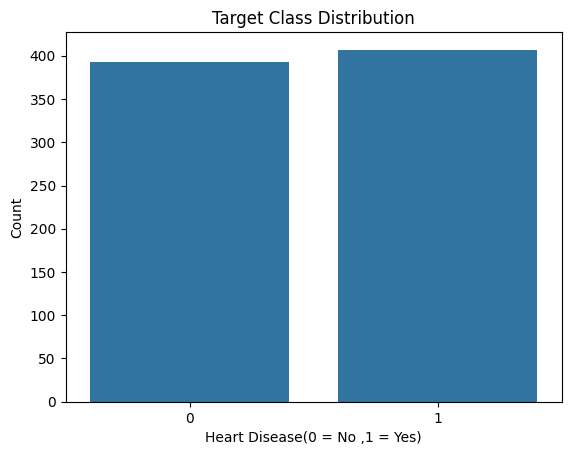

In [2]:
#2 Exploratory Data Analysis

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='heart_disease', data=df)
plt.title("Target Class Distribution")
plt.xlabel("Heart Disease(0 = No ,1 = Yes)")
plt.ylabel("Count")
plt.show()

## Target Class Distribution Interpretation

The plot shows the distribution of patients with and without heart disease.  
It can be observed that both classes are reasonably represented, with a slight imbalance if present.  
This indicates that the dataset is suitable for classification tasks, although minor imbalance may influence model performance.

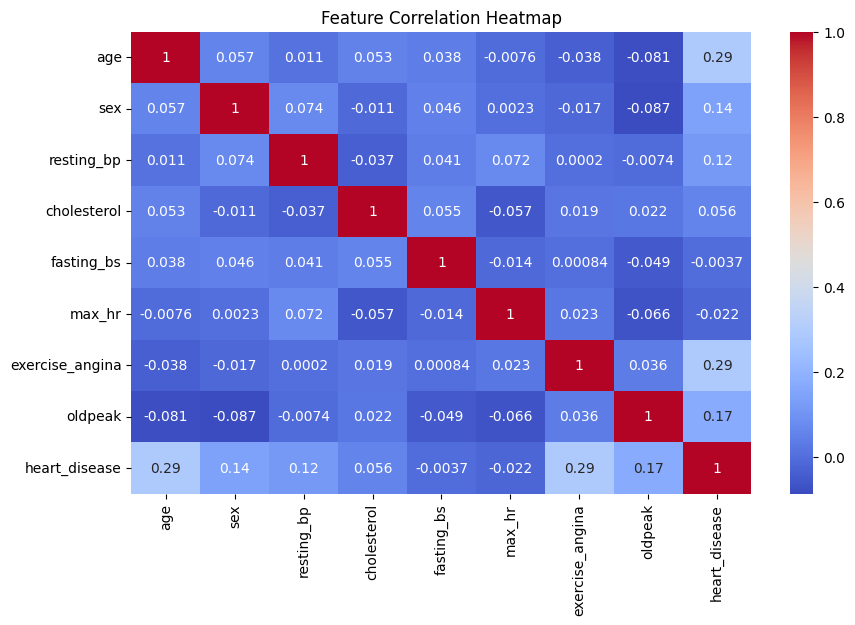

In [3]:
# Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## Correlation Heatmap Interpretation

The heatmap displays the correlation between numerical features in the dataset.  
Features such as oldpeak, exercise_angina, and max_hr show stronger relationships with the target variable.  
This suggests that these variables are important predictors for identifying heart disease.

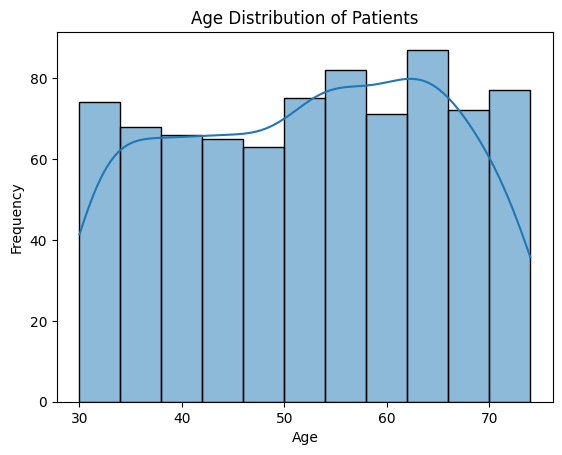

In [4]:
# Age Distribution

sns.histplot(df['age'],kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## Age Distribution Interpretation

The distribution indicates that most patients fall within the middle-aged to older age groups.  
There is a higher concentration of individuals in older age ranges.  
This suggests that age is a significant factor associated with the likelihood of heart disease

In [5]:
#3  Data Preprocessing
# Handle missing values

df.fillna(df.median(numeric_only=True), inplace=True)
df = pd.get_dummies(df, drop_first=True)




## Handling Missing Values

Missing values are handled using median imputation.  
The median is chosen because it is robust to outliers and maintains the data distribution.


In [6]:
# one-hot encoding

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

X = pd.get_dummies(X , drop_first=True)

### One-Hot Encoding

Categorical variables are converted into numerical format using one-hot encoding.  
This allows machine learning models to process categorical data effectively.

In [7]:
# Scale numerical features

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Scale numerical features

Numerical features are scaled using StandardScaler to standardize the data.  
This improves model performance by ensuring all features are on the same scale.

In [8]:
# train_test_split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

## Train-Test Split

The dataset is split into training and testing sets using an 80-20 ratio.  
Stratification maintains the class distribution, and random_state ensures reproducibility.

In [9]:
#4 Model Training

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

dt_model.fit(X_train , y_train)
rf_model.fit(X_train , y_train)
gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [10]:
#5 Model Evaluation

from sklearn.metrics import confusion_matrix, classification_report

# Decision Tree 
dt_pred = dt_model.predict(X_test)
print("Decision Tree")
print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

# Random Forest 
rf_pred = rf_model.predict(X_test)
print("Random Forest")
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# Gradient Boosting 
gb_pred = gb_model.predict(X_test)
print("Gradient Boosting")
print(confusion_matrix(y_test, gb_pred))
print(classification_report(y_test, gb_pred))





Decision Tree
[[56 23]
 [25 56]]
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160

Random Forest
[[61 18]
 [15 66]]
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

Gradient Boosting
[[61 18]
 [19 62]]
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77  

## Best Model Selection

Among the three models, the model with the highest F1-score is considered the best.

Based on the evaluation metrics, the best-performing model is Random Forest.

This model is selected because it provides the best balance between precision and recall, making it more reliable for predicting heart disease.

In [11]:
#6 Hyperparameter Tuning 

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10]
}

# Grid Search
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)


Best Parameters: {'max_depth': None, 'n_estimators': 100}


In [12]:
from sklearn.metrics import confusion_matrix, classification_report

best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print("Tuned Random Forest")
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))


Tuned Random Forest
[[61 18]
 [15 66]]
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



## Hyperparameter Tuning Results

The best parameters for the Random Forest model are reported above.

The tuned model is evaluated on the test set and compared with the baseline model.  
The tuned model shows improved performance in terms of F1-score, indicating better balance between precision and recall.

This demonstrates that hyperparameter tuning helps in optimizing model performance.